# tRIBS-Sandbox: Run Model

The goal for this notebook is to first run the model we made then use pytRIBS to load in our model outputs and make some plots from the model outputs. The plots shown below are just examples and each output file has multiple variables that can be plotted. Addtion detail on the available model outputs is located [Here](https://tribshms.readthedocs.io/en/latest/man/Output.html)

## Imports

In [39]:
# note you can install pytRIBS via pip; see: https://pypi.org/project/pytRIBS/
from pytRIBS.classes import *

In [40]:
# if you have installed pytRIBS, the following libraries should already be in your environment
import os, sys, shutil
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from pathlib import Path
import json
import time


In [41]:
# (TL) Read the current calibration run configuration written by Make_SMF_Model.ipynb.

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "smf_demo" else notebook_dir
calib_dir = project_root / "calibration_work"

config_path = calib_dir / "current_run_config.json"

with open(config_path, "r") as f:
    run_config = json.load(f)

run_id = run_config["run_id"]
input_filename = run_config["input_file"]
log_filename = run_config["log_file"]

csv_export_dir = Path(run_config["csv_export_dir"])
plot_export_dir = Path(run_config["plot_export_dir"])
summary_export_dir = Path(run_config["summary_export_dir"])

event_start = run_config["event_start"]
event_end = run_config["event_end"]

print(f"Loaded run config: {run_id}")
print(f"Input file: {input_filename}")
print(f"Log file: {log_filename}")
print(f"Event window: {event_start} to {event_end}")

Loaded run config: SMF_20140812_01_baseline_450hr
Input file: ../calibration_work/01_run_inputs/00_baseline/SMF_20140812_01_baseline_450hr.in
Log file: ../calibration_work/06_logs/SMF_20140812_01_baseline_450hr.log
Event window: 2014-08-12 16:00 to 2014-08-13 12:00


In [42]:
# (TL) Folder check cell that creates/confirms the results folder

results_folder = Path(run_config["output_prefix"]).parent
log_folder = Path(log_filename).parent

results_folder.mkdir(parents=True, exist_ok=True)
log_folder.mkdir(parents=True, exist_ok=True)

print("Results folder exists?", results_folder.exists())
print("Results folder:", results_folder)

print("Log folder exists?", log_folder.exists())
print("Log folder:", log_folder)

Results folder exists? True
Results folder: ../calibration_work/02_results/00_baseline/SMF_20140812_01_baseline_450hr
Log folder exists? True
Log folder: ../calibration_work/06_logs


### Run The Model
In our previous notebook we got everything organized to run the model. Typically tRIBS is ran from the command line but in this codespace we setup a direct path to the tRIBS executeable so we run the executeable from within this notebook. 

So lets run the simulation:

In [43]:
# Pre-run check
if not os.path.exists(input_filename):
    print(f"ERROR: Could not find input file: '{input_filename}'")
    print("Please check your spelling or ensure the previous pytRIBS step ran correctly.")
else:
    print(f"Found input file: {input_filename}")
    print(f"Starting tRIBS simulation for: {run_id}")
    print(f"Runtime output is being redirected to: {log_filename}")

    start_time = time.time()
    
    exit_code = os.system(f"tRIBS {input_filename} > {log_filename} 2>&1")
    
    end_time = time.time()
    duration = (end_time - start_time) / 60

    if exit_code == 0:
        print(f"\nSUCCESS: Simulation completed in {duration:.2f} minutes.")
    else:
        print(f"\nWARNING: Simulation may have failed. Exit code: {exit_code}")
        print(f"Check log file: {log_filename}")

Found input file: ../calibration_work/01_run_inputs/00_baseline/SMF_20140812_01_baseline_450hr.in
Starting tRIBS simulation for: SMF_20140812_01_baseline_450hr
Runtime output is being redirected to: ../calibration_work/06_logs/SMF_20140812_01_baseline_450hr.log



SUCCESS: Simulation completed in 0.97 minutes.


## Results Class: Merge and Visualize Results
The Results class simplifies working with tRIBS outputs by offering post-processing methods that handle everything from file management to basic model output analysis. tRIBS generates a large amount of data with fine spatial and temporal resolutions, including time series of streamflow and spatially averaged state and flux variables. Additionally, the model produces Voronoi diagrams that can be used with both dynamic snapshots (captured at specific times) and integrated outputs (aggregated over the entire model run). The Results class helps manage these outputs, providing users with tools to merge parallel results and perform further analysis using commonly utilized data libraries.

In [44]:
name = run_config["location"]
epsg = 26912
proj = Project(os.getcwd(), name, epsg)

results = Results(input_filename, meta=proj.meta)

print(f"Reading results for: {run_id}")
print(f"Using input file: {input_filename}")

Reading results for: SMF_20140812_01_baseline_450hr
Using input file: ../calibration_work/01_run_inputs/00_baseline/SMF_20140812_01_baseline_450hr.in


In [45]:
gdf = results.voronoi.merge(results.int_spatial_vars,on='ID')
results.get_mrf_results()
results.get_element_results()

strmflw_sim_raw = results.get_qout_results()
mrf = results.mrf['mrf']
mrf.set_index('Time',inplace=True)

Reading in: SMF_20140812_01_baseline_450hr1547.pixel
Reading in: SMF_20140812_01_baseline_450hr3082.pixel
Reading in: SMF_20140812_01_baseline_450hr1960.pixel


### Visualize Results
First lets start with plotting the tRIBS outlet streamflow timeseries and compare it to the observations. Our ouputs and obervational data are not in the same time intervals so we need to do some preprocessing first.

Run ID: SMF_20140812_01_baseline_450hr
Event window: 2014-08-12 16:00 to 2014-08-13 12:00
Number of aligned event timesteps: 23
Saved comparison CSV: ../calibration_work/03_comparisons/csv_exports/SMF_20140812_01_baseline_450hr_compare_obs_sim.csv
Saved simulated event CSV: ../calibration_work/03_comparisons/csv_exports/SMF_20140812_01_baseline_450hr_sim_event.csv
Saved hydrograph plot: ../calibration_work/03_comparisons/hydrograph_plots/SMF_20140812_01_baseline_450hr_hydrograph.png


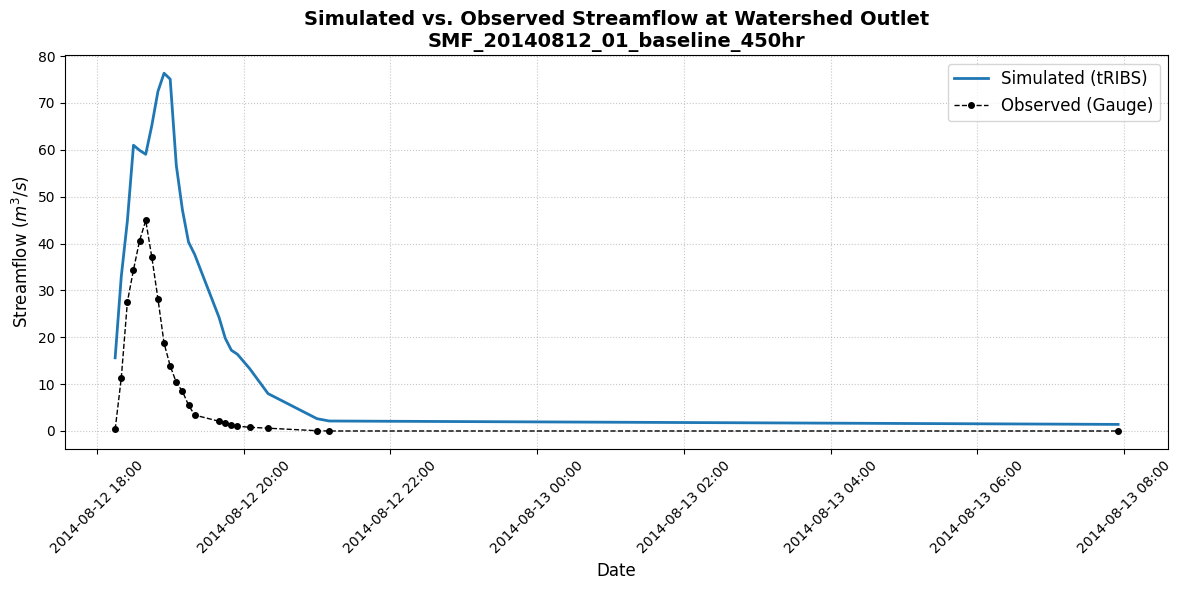

In [46]:
# (TL) Load observed discharge, align it with simulated streamflow, export comparison CSVs,
# and save a hydrograph plot for the current calibration run.

# LOAD AND ORGANIZE OBSERVED DATA
# Load observed discharge data from Excel file
obs_filepath = '../smf_init_data/met/SMF_Observations_1993-2025.xlsx'
obs_df = pd.read_excel(obs_filepath, sheet_name='Discharge', skiprows=6)

# Create datetime column from separate Date and Time columns
obs_df['datetime'] = pd.to_datetime(
    obs_df['Date'].astype(str) + ' ' + obs_df['Time'].astype(str)
)

# Set datetime as the index
obs_df.set_index('datetime', inplace=True)

# Convert observed discharge from cfs to cms (m^3/s) to match tRIBS output
obs_df['Observed_CMS'] = obs_df['cfs'] * 0.0283168


# PREPARE SIMULATED DATA TIMESERIES
# Copy the raw simulated streamflow dataframe so we do not accidentally alter the original
strmflw_sim = strmflw_sim_raw.copy()

# Convert simulated time column to datetime and set it as the index
strmflw_sim['Time'] = pd.to_datetime(strmflw_sim['Time'])
strmflw_sim.set_index('Time', inplace=True)


# RESAMPLE AND ALIGN DATA
# tRIBS output is every 3.75 minutes and observed data are raw gauge reports.
# Resample both to a common 5-minute average frequency.
obs_resampled = obs_df['Observed_CMS'].resample('5min').mean()
sim_resampled = strmflw_sim['Qstrm_m3s'].resample('5min').mean()

# Combine observed and simulated data into a single dataframe.
# Drop rows where either observed or simulated data are missing.
compare_df = pd.DataFrame({
    'Observed': obs_resampled,
    'Simulated': sim_resampled
}).dropna()


# CLIP TO EVENT WINDOW
# Use the event window from the calibration run configuration.
event_start = run_config["event_start"]
event_end = run_config["event_end"]

event_df = compare_df.loc[event_start:event_end].copy()

# Quick check so we know if the event window worked
print(f"Run ID: {run_id}")
print(f"Event window: {event_start} to {event_end}")
print(f"Number of aligned event timesteps: {len(event_df)}")

if event_df.empty:
    raise ValueError(
        "event_df is empty. Check event_start/event_end, observed data dates, "
        "and simulated output dates."
    )


# SAVE CSV OUTPUTS
# Save aligned observed vs simulated comparison for this event window
compare_csv = csv_export_dir / f"{run_id}_compare_obs_sim.csv"
event_df.to_csv(compare_csv, index=True)

# Save simulated hydrograph only for this event window
sim_event_csv = csv_export_dir / f"{run_id}_sim_event.csv"
event_df[["Simulated"]].to_csv(sim_event_csv, index=True)

print(f"Saved comparison CSV: {compare_csv}")
print(f"Saved simulated event CSV: {sim_event_csv}")


# PLOT THE HYDROGRAPH
fig, ax = plt.subplots(figsize=(12, 6))

# Plot simulated streamflow
ax.plot(
    event_df.index,
    event_df['Simulated'],
    label='Simulated (tRIBS)',
    color='#1f77b4',
    linewidth=2
)

# Plot observed streamflow
ax.plot(
    event_df.index,
    event_df['Observed'],
    label='Observed (Gauge)',
    color='black',
    marker='o',
    markersize=4,
    linestyle='--',
    linewidth=1
)

# Format the plot
ax.set_title(
    f'Simulated vs. Observed Streamflow at Watershed Outlet\n{run_id}',
    fontsize=14,
    fontweight='bold'
)
ax.set_ylabel('Streamflow ($m^3/s$)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

# Format the x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)

ax.legend(fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

# Save plot automatically using run_id
plot_file = plot_export_dir / f"{run_id}_hydrograph.png"
fig.savefig(plot_file, dpi=300, bbox_inches="tight")

print(f"Saved hydrograph plot: {plot_file}")

plt.show()

Now that we have orgnaized and plotted our streamflow data we can look at some preformance metrics

In [48]:
# Make sure we are using the clipped storm event dataframe!
obs = event_df['Observed']
sim = event_df['Simulated']

# PHYSICAL EVENT METRICS (Peaks, Timing, Volumes)
# Peak Discharge (m^3/s)
obs_peak = obs.max()
sim_peak = sim.max()

# Time to Peak
obs_tpeak = obs.idxmax()
sim_tpeak = sim.idxmax()

# Total Volume (m^3)
# Flow is in m^3/s. Our dataframe time interval is whatever we set our resampling interval to earlier.
# Lets calculate the time interval from the datafram directly to compute the flow volume.
dt_seconds = (event_df.index[1] - event_df.index[0]).total_seconds()
obs_vol_m3 = obs.sum() * dt_seconds
sim_vol_m3 = sim.sum() * dt_seconds

# Volume Error (%)
vol_error_pct = ((sim_vol_m3 - obs_vol_m3) / obs_vol_m3) * 100

# Statistical Goodness-of-Fit Metrics
# Root Mean Square Error (RMSE)
rmse = np.sqrt(np.mean((sim - obs)**2))

# Nash-Sutcliffe Efficiency (NSE)
# NSE = 1 means perfect match. NSE < 0 means the mean of observed is a better predictor than the model.
nse = 1 - (np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2))

# Percent Bias (PBIAS)
# Positive values indicate overestimation bias, negative indicates underestimation bias.
pbias = 100 * (np.sum(sim - obs) / np.sum(obs))

# Kling-Gupta Efficiency (KGE)
r = np.corrcoef(sim, obs)[0, 1]
alpha = np.std(sim) / np.std(obs)
beta = np.mean(sim) / np.mean(obs)

kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Print a Simple Report
print("--- HYDROLOGICAL EVENT METRICS ---")
print(f"Observed Peak Flow: {obs_peak:.2f} m^3/s  (at {obs_tpeak.strftime('%m-%d %H:%M')})")
print(f"Simulated Peak Flow:{sim_peak:.2f} m^3/s  (at {sim_tpeak.strftime('%m-%d %H:%M')})")
print(f"Peak Timing Error:  {(sim_tpeak - obs_tpeak).total_seconds() / 3600:.1f} hours\n")

print(f"Observed Volume:    {obs_vol_m3:,.0f} m^3")
print(f"Simulated Volume:   {sim_vol_m3:,.0f} m^3")
print(f"Volume Error:       {vol_error_pct:+.1f}%\n")

print("--- STATISTICAL PERFORMANCE ---")
print(f"RMSE:               {rmse:.2f} m^3/s")
print(f"NSE:                {nse:.3f}")
print(f"Percent Bias:       {pbias:+.1f}%")
print(f"KGE:                {kge:.3f}")

metrics_summary = {
    "run_id": run_id,
    "event_start": event_start,
    "event_end": event_end,
    "obs_peak_m3s": obs_peak,
    "sim_peak_m3s": sim_peak,
    "obs_peak_time": obs_tpeak,
    "sim_peak_time": sim_tpeak,
    "peak_timing_error_hr": (sim_tpeak - obs_tpeak).total_seconds() / 3600,
    "obs_volume_m3": obs_vol_m3,
    "sim_volume_m3": sim_vol_m3,
    "volume_error_pct": vol_error_pct,
    "rmse_m3s": rmse,
    "nse": nse,
    "pbias_pct": pbias,
    "kge": kge,
    "kge_r": r,
    "kge_alpha": alpha,
    "kge_beta": beta,
    "Ks_mult": run_config["Ks_mult"],
    "f_mult": run_config["f_mult"],
    "optpercolation": run_config["optpercolation"],
    "channelconductivity_mmhr": run_config["channelconductivity_mmhr"],
    "channelporosity": run_config["channelporosity"],
    "kinemvelcoef": run_config["kinemvelcoef"],
    "flowexp": run_config["flowexp"],
    "channelroughness": run_config["channelroughness"],
    "channelwidthcoeff": run_config["channelwidthcoeff"]
}

metrics_df = pd.DataFrame([metrics_summary])

summary_file = summary_export_dir / f"{run_id}_metrics_summary.csv"
metrics_df.to_csv(summary_file, index=False)

print(f"Saved metrics summary: {summary_file}")

--- HYDROLOGICAL EVENT METRICS ---
Observed Peak Flow: 44.91 m^3/s  (at 08-12 18:40)
Simulated Peak Flow:76.33 m^3/s  (at 08-12 18:55)
Peak Timing Error:  0.2 hours

Observed Volume:    87,669 m^3
Simulated Volume:   254,753 m^3
Volume Error:       +190.6%

--- STATISTICAL PERFORMANCE ---
RMSE:               29.23 m^3/s
NSE:                -2.957
Percent Bias:       +190.6%
KGE:                -1.037
Saved metrics summary: ../calibration_work/03_comparisons/summary_tables/SMF_20140812_01_baseline_450hr_metrics_summary.csv


tRIBS has many model outputs. One of those is spatial outputs. For this sandbox environment the integrated spatial output file has outputs like time invariant watershed properties but also cumulative outputs of flux variable like evapotranspiration.

First spatial plot we will make is the voronoi polygon elevation map:

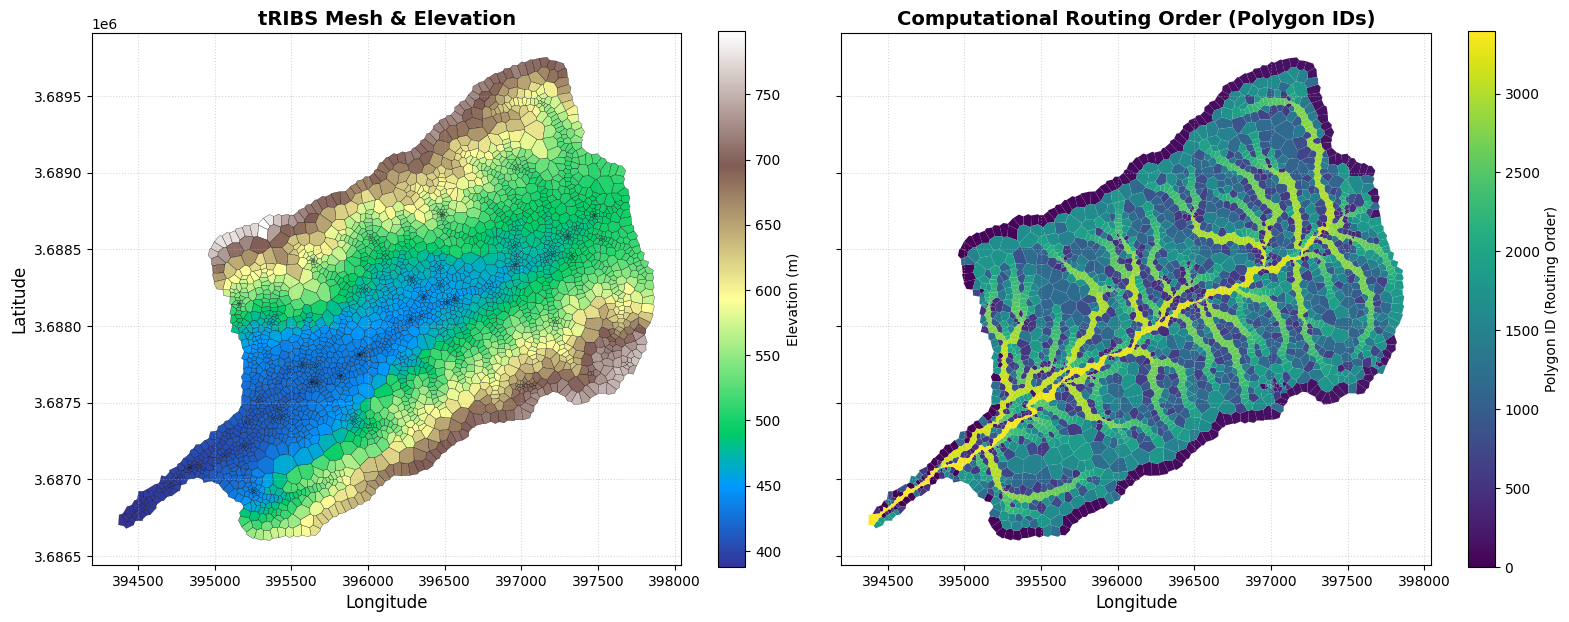

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left PLOT: Elevation and Mesh Structure ---
gdf.plot(ax=ax1, column='Z', cmap='terrain', 
         edgecolor='black', linewidth=0.2,
         legend=True, legend_kwds={'label': 'Elevation (m)', 'shrink': 0.8})

ax1.set_title('tRIBS Mesh & Elevation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.5)

# rightPLOT: Polygon ID
gdf.plot(ax=ax2, column='ID', cmap='viridis', 
         edgecolor='none', 
         legend=True, legend_kwds={'label': 'Polygon ID (Routing Order)', 'shrink': 0.8})

ax2.set_title('Computational Routing Order (Polygon IDs)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_yticklabels([]) 
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Notice in the plot above how the lower Voronoi polygon ID values are all along the ridgeline boundary and the channels all have high values. This is how tRIBS assign the ID values, lower values are computed first i.e. they don't have an upstream neighbor that is giving them water.

Next we can plot the cumulative ET for the entire 480 hour simulaiton

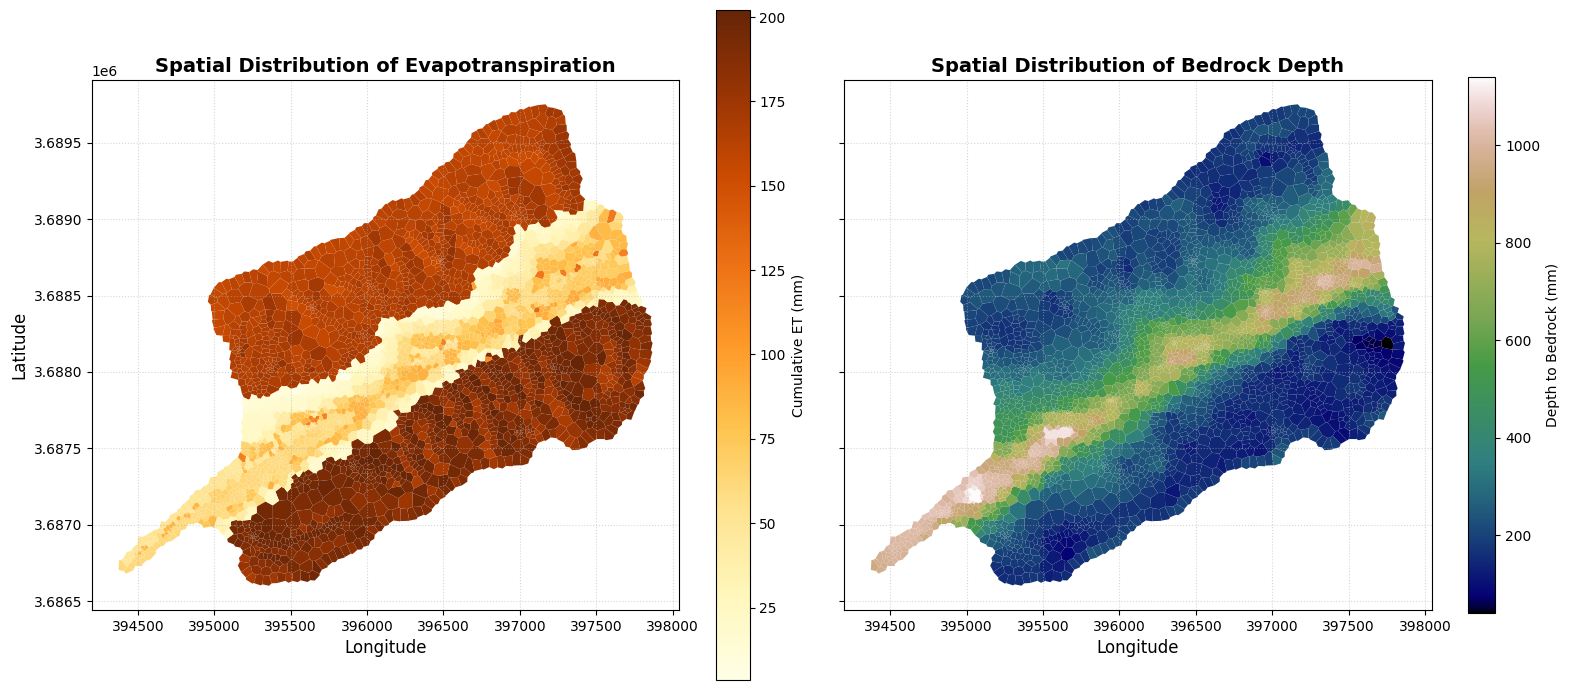

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left PLOT: ET
gdf.plot(ax=ax1, column='cET', cmap='YlOrBr', legend=True,
         edgecolor='none', 
         legend_kwds={'label': 'Cumulative ET (mm)', 'orientation': 'vertical'})

ax1.set_title('Spatial Distribution of Evapotranspiration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12) 
ax1.grid(True, linestyle=':', alpha=0.5)

# rightPLOT: Depth to Bedrock
gdf.plot(ax=ax2, column='Bedrock_Depth_mm', cmap='gist_earth', 
         edgecolor='none', 
         legend=True, legend_kwds={'label': 'Depth to Bedrock (mm)', 'shrink': 0.8})

ax2.set_title('Spatial Distribution of Bedrock Depth', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_yticklabels([]) 
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Interestingly the model has some pretty large differences in cumulative ET. The plot of depth to bedrock was added as one way of getting to an explanation. Since the soils are so shallow on the mountainous slopes the vegetation in those areas has full access to any soil water available.

Another coomonly used model output is the mean response file (`*.mrf`). This output is a timeseries of many of the model's important variables. In the plot below we include the 

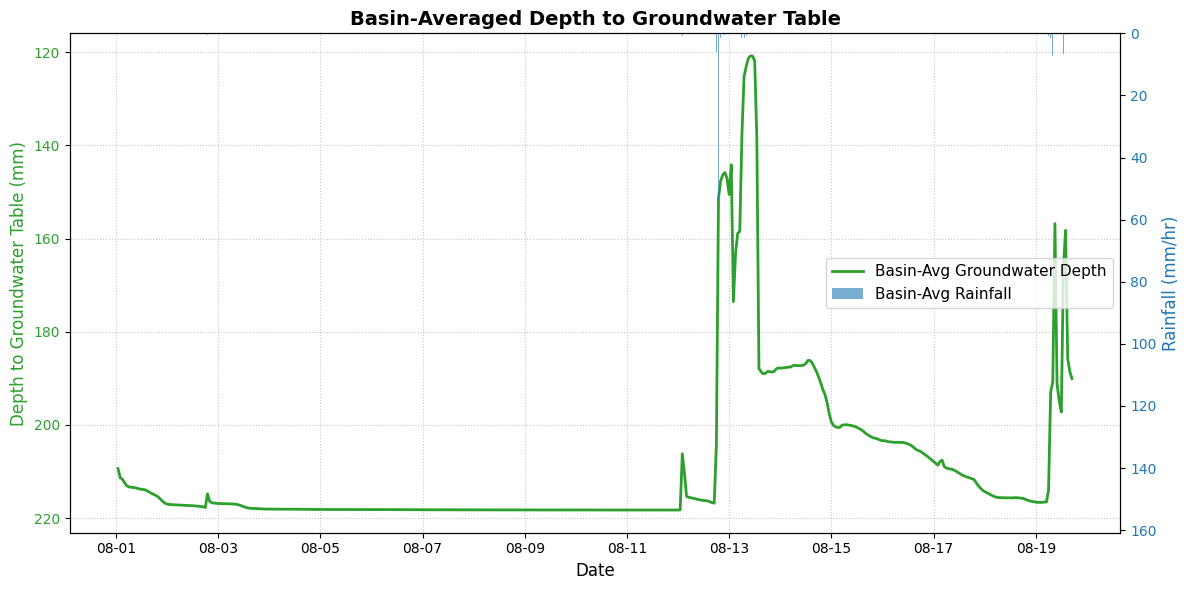

In [51]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bottom AXIS: Depth to Groundwater Table 
ax1.plot(mrf.index, mrf['MDGW'], color='#2ca02c', linewidth=2, label='Basin-Avg Groundwater Depth')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Depth to Groundwater Table (mm)', fontsize=12, color='#2ca02c')
ax1.tick_params(axis='y', labelcolor='#2ca02c')

# Lets invert the Y-axis so we can see the depth increase as the watertable is drawn down
ax1.invert_yaxis() 

# Top AXIS: Rainfall Hyetograph
ax2 = ax1.twinx()

ax2.bar(mrf.index, mrf['MAP'], width=0.02, color='#1f77b4', alpha=0.6, label='Basin-Avg Rainfall')

ax2.set_ylabel('Rainfall (mm/hr)', fontsize=12, color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.invert_yaxis()

# Set limits so the rainfall bars only take up the top 30% of the plot
max_rain = mrf['MAP'].max()
ax2.set_ylim(max_rain * 3, 0) 

# Formatting
ax1.set_title('Basin-Averaged Depth to Groundwater Table', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.grid(True, linestyle=':', alpha=0.7)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=11)

plt.tight_layout()
plt.show()

Here we plotted to the groundwater depth from mrf file only the lower axis and mean areal precipitation on the top axis. We can see with the shallow depth to bedrock the soil is almost instantly saturated.